# Speech-to-song versus prose-to-lyrics analysis

This notebook analyzes the PsyNet simulated export for the reviewed 3-sentence subset. The data were generated by local PsyNet bots, not by real participants. Text bot ratings use a deterministic LLM-style prompt fallback; audio bot ratings use a documented metadata fallback rather than waveform analysis.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import tempfile

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 45

zip_path = Path("../simulated_data.zip")
assert zip_path.exists(), zip_path

with tempfile.TemporaryDirectory() as tmpdir:
    with ZipFile(zip_path) as archive:
        archive.extractall(tmpdir)
    candidates = sorted(Path(tmpdir).glob("**/regular/basic_data/trial.csv"))
    assert candidates, "regular/basic_data/trial.csv not found in export"
    trial_csv = candidates[0]
    trials = pd.read_csv(trial_csv)

trials.head()

,trial_id,participant_id,phase,sentence_id,sentence_text,repetition_level,n_presentations,presented_transcript,rating,rating_label,transformation_score,audio_path,audio_duration_sec,bot_decision_source,trial_position,score
0,1,1,text,s09,how fast does a Zamboni go?,0,1,how fast does a Zamboni go?,0,0 - Definitely speech,0.0000,data/audio/s09_rep0.wav,2.217,text_prompt_fallback,0,0.0000
1,5,1,text,s09,how fast does a Zamboni go?,3,4,how fast does a Zamboni go? how fast does a Za...,3,3 - Equally speech and song,0.5000,data/audio/s09_rep3.wav,9.918,text_prompt_fallback,4,0.5000
2,3,1,text,s01,I love you,2,3,I love you I love you I love you,3,3 - Equally speech and song,0.5000,data/audio/s01_rep2.wav,3.595,text_prompt_fallback,2,0.5000
3,2,1,text,s01,I love you,3,4,I love you I love you I love you I love you,4,4,0.6667,data/audio/s01_rep3.wav,4.910,text_prompt_fallback,1,0.6667
4,4,1,text,s09,how fast does a Zamboni go?,1,2,how fast does a Zamboni go? how fast does a Za...,1,1,0.1667,data/audio/s09_rep1.wav,4.784,text_prompt_fallback,3,0.1667


In [2]:
expected_cols = {
    "participant_id", "phase", "sentence_id", "sentence_text",
    "repetition_level", "rating", "transformation_score",
    "bot_decision_source",
}
missing = expected_cols - set(trials.columns)
assert not missing, missing

summary_counts = (
    trials.groupby(["phase", "sentence_id", "repetition_level"])
    .size()
    .rename("n_trials")
    .reset_index()
)
summary_counts.head(10)

,phase,sentence_id,repetition_level,n_trials
0,audio,s01,0,6
1,audio,s01,1,6
2,audio,s01,2,6
3,audio,s01,3,6
4,audio,s01,4,6
5,audio,s09,0,6
6,audio,s09,1,6
7,audio,s09,2,6
8,audio,s09,3,6
9,audio,s09,4,6


In [3]:
phase_summary = (
    trials.groupby(["phase", "repetition_level"])
    .agg(
        mean_score=("transformation_score", "mean"),
        sem_score=("transformation_score", "sem"),
        n=("transformation_score", "size"),
    )
    .reset_index()
)
phase_summary

,phase,repetition_level,mean_score,sem_score,n
0,audio,0,0.055567,0.019059,18
1,audio,1,0.222233,0.019048,18
2,audio,2,0.555567,0.019059,18
3,audio,3,0.722233,0.019048,18
4,audio,4,0.888867,0.019059,18
5,text,0,0.055567,0.019059,18
6,text,1,0.222233,0.019048,18
7,text,2,0.388867,0.019059,18
8,text,3,0.555567,0.019059,18
9,text,4,0.722233,0.019048,18


In [4]:
sentence_summary = (
    trials.groupby(["phase", "sentence_id", "sentence_text", "repetition_level"])
    .agg(mean_score=("transformation_score", "mean"), n=("transformation_score", "size"))
    .reset_index()
)
sentence_summary.head(15)

,phase,sentence_id,sentence_text,repetition_level,mean_score,n
0,audio,s01,I love you,0,0.1667,6
1,audio,s01,I love you,1,0.3333,6
2,audio,s01,I love you,2,0.6667,6
3,audio,s01,I love you,3,0.8333,6
4,audio,s01,I love you,4,1.0000,6
5,audio,s09,how fast does a Zamboni go?,0,0.0000,6
6,audio,s09,how fast does a Zamboni go?,1,0.1667,6
7,audio,s09,how fast does a Zamboni go?,2,0.5000,6
8,audio,s09,how fast does a Zamboni go?,3,0.6667,6
9,audio,s09,how fast does a Zamboni go?,4,0.8333,6


In [5]:
wide = sentence_summary.pivot_table(
    index=["sentence_id", "sentence_text", "repetition_level"],
    columns="phase",
    values="mean_score",
).reset_index()
correlation = wide["text"].corr(wide["audio"])
print(f"Text/audio sentence x repetition correlation: {correlation:.3f}")
wide

Text/audio sentence x repetition correlation: 0.989


phase,sentence_id,sentence_text,repetition_level,audio,text
0,s01,I love you,0,0.1667,0.1667
1,s01,I love you,1,0.3333,0.3333
2,s01,I love you,2,0.6667,0.5000
3,s01,I love you,3,0.8333,0.6667
4,s01,I love you,4,1.0000,0.8333
5,s09,how fast does a Zamboni go?,0,0.0000,0.0000
6,s09,how fast does a Zamboni go?,1,0.1667,0.1667
7,s09,how fast does a Zamboni go?,2,0.5000,0.3333
8,s09,how fast does a Zamboni go?,3,0.6667,0.5000
9,s09,how fast does a Zamboni go?,4,0.8333,0.6667


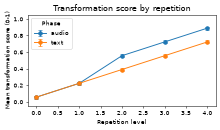

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
for phase, group in phase_summary.groupby("phase"):
    group = group.sort_values("repetition_level")
    ax.errorbar(
        group["repetition_level"],
        group["mean_score"],
        yerr=group["sem_score"].fillna(0),
        marker="o",
        capsize=3,
        label=phase,
    )
ax.set_xlabel("Repetition level")
ax.set_ylabel("Mean transformation score (0-1)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Transformation score by repetition")
ax.legend(title="Phase")
fig.tight_layout()
plt.show()

In [7]:
sentence_profiles = wide.copy()
sentence_profiles["audio_minus_text"] = sentence_profiles["audio"] - sentence_profiles["text"]
sentence_profiles.sort_values(["sentence_id", "repetition_level"])

phase,sentence_id,sentence_text,repetition_level,audio,text,audio_minus_text
0,s01,I love you,0,0.1667,0.1667,0.0000
1,s01,I love you,1,0.3333,0.3333,0.0000
2,s01,I love you,2,0.6667,0.5000,0.1667
3,s01,I love you,3,0.8333,0.6667,0.1666
4,s01,I love you,4,1.0000,0.8333,0.1667
5,s09,how fast does a Zamboni go?,0,0.0000,0.0000,0.0000
6,s09,how fast does a Zamboni go?,1,0.1667,0.1667,0.0000
7,s09,how fast does a Zamboni go?,2,0.5000,0.3333,0.1667
8,s09,how fast does a Zamboni go?,3,0.6667,0.5000,0.1667
9,s09,how fast does a Zamboni go?,4,0.8333,0.6667,0.1666


## Interpretation

The simulated bot data contain balanced observations for both phases: 3 sentences x 5 repetition levels x 6 bots. The deterministic fallback policy produces increasing transformation scores as repetition increases, with audio ratings higher than text ratings at larger repetition levels. These results validate the analysis pipeline and export shape; they are not behavioral evidence from human participants or waveform-aware audio-model judgments.